In [336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn import preprocessing
import pickle


from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression as lr
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.ensemble import GradientBoostingClassifier as gb
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.metrics import roc_auc_score
from sklearn.base import clone


In [337]:
file_path = "UDS.csv"

read_func = pd.read_excel if file_path.lower().endswith("xlsx") else pd.read_csv
df = read_func(file_path, low_memory=False)

print(f"✅ Dataset carregado com sucesso!")
print(f"Formato: {df.shape[0]} linhas × {df.shape[1]} colunas")

display(df.head())
print("\nColunas disponíveis:")
print(list(df.columns))


✅ Dataset carregado com sucesso!
Formato: 205908 linhas × 1024 colunas


,NACCID,NACCADC,PACKET,FORMVER,VISITMO,VISITDAY,VISITYR,NACCVNUM,NACCAVST,NACCNVST,...,NPATGAM1,NPATGAM2,NPATGAM3,NPATGAM4,NPATGAM5,NPATGFRN,NPATGFR1,NPATGFR2,NPATGFR3,NPATGFR4
0,NACC002909,186,I,3.0,12,28,2022,1,3,3,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
1,NACC002909,186,F,3.0,1,23,2024,2,3,3,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
2,NACC002909,186,F,3.0,3,5,2025,3,3,3,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
3,NACC003142,186,I,3.0,2,11,2025,1,1,1,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
4,NACC003487,186,I,3.0,11,15,2023,1,2,2,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4



Colunas disponíveis:
['NACCID', 'NACCADC', 'PACKET', 'FORMVER', 'VISITMO', 'VISITDAY', 'VISITYR', 'NACCVNUM', 'NACCAVST', 'NACCNVST', 'NACCDAYS', 'NACCFDYS', 'NACCCORE', 'NACCREAS', 'NACCREFR', 'BIRTHMO', 'BIRTHYR', 'SEX', 'HISPANIC', 'HISPOR', 'HISPORX', 'RACE', 'RACEX', 'RACESEC', 'RACESECX', 'RACETER', 'RACETERX', 'PRIMLANG', 'PRIMLANX', 'EDUC', 'MARISTAT', 'NACCLIVS', 'INDEPEND', 'RESIDENC', 'HANDED', 'INBIRMO', 'INBIRYR', 'INSEX', 'NEWINF', 'INHISP', 'INHISPOR', 'INHISPOX', 'NACCNINR', 'INRACE', 'INRACEX', 'INRASEC', 'INRASECX', 'INRATER', 'INRATERX', 'INEDUC', 'INRELTO', 'INRELTOX', 'INKNOWN', 'INLIVWTH', 'INVISITS', 'INCALLS', 'INRELY', 'NACCFAM', 'NACCMOM', 'NACCDAD', 'NACCAM', 'NACCAMX', 'NACCAMS', 'NACCAMSX', 'NACCFM', 'NACCFMX', 'NACCFMS', 'NACCFMSX', 'NACCOM', 'NACCOMX', 'NACCOMS', 'NACCOMSX', 'NACCFADM', 'NACCFFTD', 'ANYMEDS', 'DRUG1', 'DRUG2', 'DRUG3', 'DRUG4', 'DRUG5', 'DRUG6', 'DRUG7', 'DRUG8', 'DRUG9', 'DRUG10', 'DRUG11', 'DRUG12', 'DRUG13', 'DRUG14', 'DRUG15', 'DRUG1

### PRE PROCESSING

In [338]:
vars_diagnostico = [
    "NACCPDMD", "PD", "PARKSIGN", "PARKGAIT", "PARK",
    "DATSCAN", "NACCLBDS", "LBDEVAL", "NACCLBDE", "NACCLBDP",
    "PDOTHR", "PDOTHRYR"
]

vars_motor = [
    "BRADYKIN", "BRADYKIX", "POSTURE", "POSTUREX", "GAIT", "GAITX",
    "POSSTAB", "POSSTABX", "PDNORMAL"
]

vars_rigidez = [
    "RIGDNECK", "RIGDNEX", "RIGDUPRT", "RIGDUPRX",
    "RIGDUPLF", "RIGDUPLX", "RIGDLORT", "RIGDLORX",
    "RIGDLOLF", "RIGDLOLX"
]

vars_tremor_mov = [
    "TRESTFAC", "TRESTFAX", "TRESTRHD", "TRESTRHX",
    "TRESTLHD", "TRESTLHX", "TRESTRFT", "TRESTRFX",
    "TRESTLFT", "TRESTLFX", "TRACTRHD", "TRACTRHX",
    "TRACTLHD", "TRACTLHX", "TAPSRT", "TAPSRTX",
    "TAPSLF", "TAPSLFX", "HANDMOVR", "HANDMVRX",
    "HANDMOVL", "HANDMVLX", "HANDALTR", "HANDATRX",
    "HANDALTL", "HANDATLX", "LEGRT", "LEGRTX",
    "LEGLF", "LEGLFX", "ARISING", "ARISINGX"
]

vars_fala_expressao = [
    "SPEECH", "SPEECHX", "FACEXP", "FACEXPX"
]

vars_familia = [
    "MOMOPARK", "PARKAGE"
]

vars_all = (
    vars_diagnostico
    + vars_motor
    + vars_rigidez
    + vars_tremor_mov
    + vars_fala_expressao
    + vars_familia
)

present = [v for v in vars_all if v in df.columns]
missing = [v for v in vars_all if v not in df.columns]

print(f"Total de variáveis listadas: {len(vars_all)}")
print(f"Encontradas no dataset: {len(present)}")
print(f"Ausentes: {len(missing)}")

if missing:
    print("\nVariáveis não encontradas (ausentes no seu arquivo):")
    print(missing)

summary = (
    df[present]
    .notna()
    .mean()
    .reset_index()
    .rename(columns={"index": "Variável", 0: "% Preenchido"})
)


type_map = df[present].dtypes

summary['Tipo'] = summary['Variável'].map(type_map)


summary["% Preenchido"] = (summary["% Preenchido"] * 100).round(2)

summary = summary[['Variável', 'Tipo', '% Preenchido']]

summary = summary.sort_values("% Preenchido", ascending=False)

print("\n📋 Percentual de preenchimento e Tipos de Dados:")
display(summary)


def cat_summary(cat_name, vars_list):
    found = [v for v in vars_list if v in present]
    print(f"\n📂 {cat_name} — {len(found)} variáveis encontradas:")
    print(found if found else "Nenhuma encontrada.")

cat_summary("Diagnóstico (Parkinson / Lewy)", vars_diagnostico)
cat_summary("Exame motor", vars_motor)
cat_summary("Rigidez", vars_rigidez)
cat_summary("Tremor e movimentos", vars_tremor_mov)
cat_summary("Fala e expressão facial", vars_fala_expressao)
cat_summary("Histórico familiar", vars_familia)

Total de variáveis listadas: 69
Encontradas no dataset: 69
Ausentes: 0

📋 Percentual de preenchimento e Tipos de Dados:


,Variável,Tipo,% Preenchido
0,NACCPDMD,int64,100.00
25,RIGDUPLF,int64,100.00
29,RIGDLOLF,int64,100.00
31,TRESTFAC,int64,100.00
33,TRESTRHD,int64,100.00
...,...,...,...
38,TRESTRFX,object,0.03
36,TRESTLHX,object,0.03
66,FACEXPX,object,0.03
34,TRESTRHX,object,0.03



📂 Diagnóstico (Parkinson / Lewy) — 12 variáveis encontradas:
['NACCPDMD', 'PD', 'PARKSIGN', 'PARKGAIT', 'PARK', 'DATSCAN', 'NACCLBDS', 'LBDEVAL', 'NACCLBDE', 'NACCLBDP', 'PDOTHR', 'PDOTHRYR']

📂 Exame motor — 9 variáveis encontradas:
['BRADYKIN', 'BRADYKIX', 'POSTURE', 'POSTUREX', 'GAIT', 'GAITX', 'POSSTAB', 'POSSTABX', 'PDNORMAL']

📂 Rigidez — 10 variáveis encontradas:
['RIGDNECK', 'RIGDNEX', 'RIGDUPRT', 'RIGDUPRX', 'RIGDUPLF', 'RIGDUPLX', 'RIGDLORT', 'RIGDLORX', 'RIGDLOLF', 'RIGDLOLX']

📂 Tremor e movimentos — 32 variáveis encontradas:
['TRESTFAC', 'TRESTFAX', 'TRESTRHD', 'TRESTRHX', 'TRESTLHD', 'TRESTLHX', 'TRESTRFT', 'TRESTRFX', 'TRESTLFT', 'TRESTLFX', 'TRACTRHD', 'TRACTRHX', 'TRACTLHD', 'TRACTLHX', 'TAPSRT', 'TAPSRTX', 'TAPSLF', 'TAPSLFX', 'HANDMOVR', 'HANDMVRX', 'HANDMOVL', 'HANDMVLX', 'HANDALTR', 'HANDATRX', 'HANDALTL', 'HANDATLX', 'LEGRT', 'LEGRTX', 'LEGLF', 'LEGLFX', 'ARISING', 'ARISINGX']

📂 Fala e expressão facial — 4 variáveis encontradas:
['SPEECH', 'SPEECHX', 'FACEXP', '

In [339]:
threshold = 0.8  
vars_good = (
    summary.loc[summary["% Preenchido"] >= threshold * 100, "Variável"]
    .tolist()
)

df_park = df[vars_good].copy()

print(f"✅ {len(vars_good)} variáveis mantidas (preenchimento ≥ 80%)")

✅ 42 variáveis mantidas (preenchimento ≥ 80%)


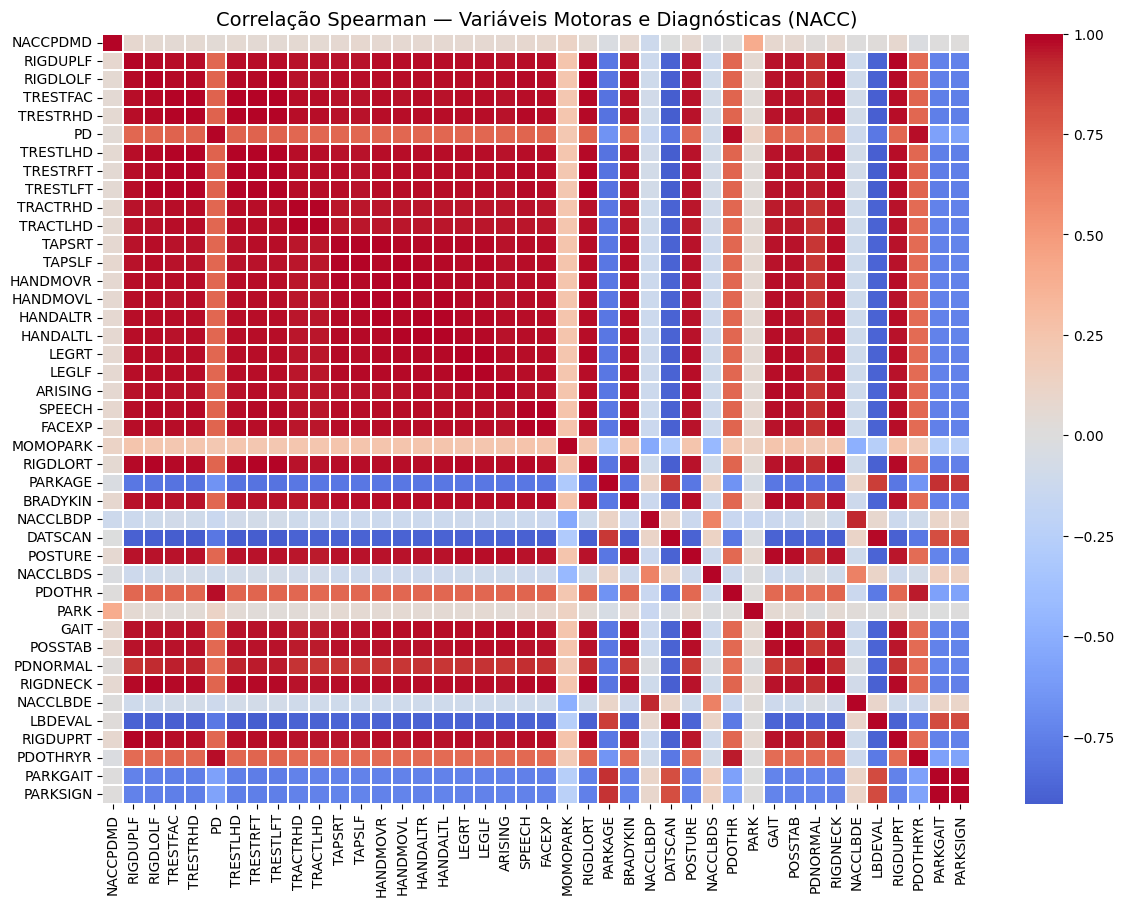

Lista de variáveis com bom preenchimento salva em 'vars_park_lewy_usable.txt'.


In [340]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_park.corr(method="spearman"),
    cmap="coolwarm", center=0, linewidths=0.3
)
plt.title("Correlação Spearman — Variáveis Motoras e Diagnósticas (NACC)", fontsize=14)
plt.show()


with open("vars_park_lewy_usable.txt", "w") as f:
    for col in vars_good:
        f.write(col + "\n")
print("Lista de variáveis com bom preenchimento salva em 'vars_park_lewy_usable.txt'.")

In [341]:
tabela_nacc = (
        df["DEMENTED"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência")
    )
tabela_nacc["%"] = (tabela_nacc["Frequência"] / tabela_nacc["Frequência"].sum() * 100).round(2)

print("\nDistribuição da variável DEMENTED:")
display(tabela_nacc)



Distribuição da variável DEMENTED:


,Código Diagnóstico,Frequência,%
0,0,146336,71.07
1,1,59572,28.93


In [342]:

tabela_nacc = (
        df["NACCUDSD"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência")
    )
tabela_nacc["%"] = (tabela_nacc["Frequência"] / tabela_nacc["Frequência"].sum() * 100).round(2)

print("\nDistribuição da variável NACCUDSD:")
display(tabela_nacc)


Distribuição da variável NACCUDSD:


,Código Diagnóstico,Frequência,%
0,1,100992,49.05
1,2,9090,4.41
2,3,36254,17.61
3,4,59572,28.93


 Usando 'DEMENTED' como variável alvo (diagnóstico de demência).
✅ Pacientes com Parkinson filtrados: 10184 registros
🎯 Total de features usadas: 42
🧩 Dimensões do dataset final: (10184, 42)

Distribuição da variável alvo:
DEMENTED
0    6317
1    3867
Name: count, dtype: int64


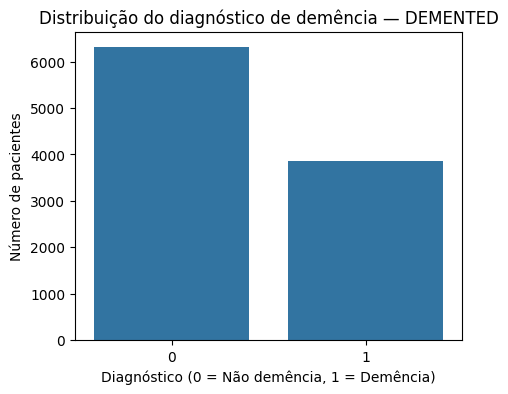

✅ Dados finais prontos para modelagem: 10184 pacientes, 42 variáveis.


In [343]:
target_col = "DEMENTED"
print(f" Usando '{target_col}' como variável alvo (diagnóstico de demência).")


parkinson_cols = ["PD", "NACCPDMD"]
parkinson_found = [c for c in parkinson_cols if c in df.columns]

if not parkinson_found:
    raise ValueError("Nenhuma variável de Parkinson encontrada (PD / NACCPDMD).")

mask_park = np.zeros(len(df), dtype=bool)
for c in parkinson_found:
    mask_park |= (df[c] == 1)

df_parkinson = df.loc[mask_park].copy()
print(f"✅ Pacientes com Parkinson filtrados: {df_parkinson.shape[0]} registros")


with open("vars_park_lewy_usable.txt", "r") as f:
    feature_cols = [line.strip() for line in f.readlines() if line.strip()]

feature_cols = [c for c in feature_cols if c in df_parkinson.columns]

X = df_parkinson[feature_cols].copy()
y = df_parkinson[target_col].copy()

print(f"🎯 Total de features usadas: {len(feature_cols)}")
print(f"🧩 Dimensões do dataset final: {X.shape}")



y_counts = y.value_counts(dropna=False)
print("\nDistribuição da variável alvo:")
print(y_counts)

plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title(f"Distribuição do diagnóstico de demência — {target_col}")
plt.xlabel("Diagnóstico (0 = Não demência, 1 = Demência)")
plt.ylabel("Número de pacientes")
plt.show()


mask_valid = y.notna() & X.notna().all(axis=1)
X = X.loc[mask_valid]
y = y.loc[mask_valid]

print(f"✅ Dados finais prontos para modelagem: {X.shape[0]} pacientes, {X.shape[1]} variáveis.")


In [344]:
print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"Validação cruzada configurada: {n_splits} folds (Stratified)")

unique, counts = np.unique(y, return_counts=True)
print("\n📈 Distribuição da variável alvo:")
for label, count in zip(unique, counts):
    pct = count / sum(counts) * 100
    print(f"Classe {label}: {count} amostras ({pct:.1f}%)")

Formato de X: (10184, 42)
Formato de y: (10184,)
Validação cruzada configurada: 5 folds (Stratified)

📈 Distribuição da variável alvo:
Classe 0: 6317 amostras (62.0%)
Classe 1: 3867 amostras (38.0%)


In [ ]:

def impute(raw_data):
   
    data = raw_data.copy()
    for var_ind in range(data.shape[1]):
        variable = data[:, var_ind]
        if np.sum(pd.isnull(variable)) > 0:
            sample = variable[~pd.isnull(variable)]
            if len(sample) > 0:
                replace_vals = np.random.choice(sample, np.sum(pd.isnull(variable)), replace=True)
                variable[pd.isnull(variable)] = replace_vals
                data[:, var_ind] = variable
    return data

print("\n🧩 Aplicando imputação de valores faltantes (estilo James)...")
X_array = X.values  
X_imputed = impute(X_array)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

X = X_imputed_df

print(f"✅ Imputação concluída — Shape: {X.shape} | NaN restantes: {np.isnan(X).sum().sum()}")



🧩 Aplicando imputação de valores faltantes (estilo James)...
✅ Imputação concluída — Shape: (10184, 42) | NaN restantes: 0


In [346]:
#X_scaled = preprocessing.scale(X)
#print("Dados escalonados com preprocessing.scale")

#y_array = y.to_numpy()

#print(f"Dataset final pronto: {X_scaled.shape[0]} amostras × {X_scaled.shape[1]} variáveis.")
#print(f"Distribuição da variável alvo: {np.bincount(y_array)} (0=Não Dem, 1=Dem)")


In [348]:
diagnostic_cols= [ 'NACCLBDE', 'NACCLBDP', 'NACCLBDS', 'LBDEVAL' ]
#diagnostic_cols = [
 #  'NACCPDMD','PD','PARKSIGN','PARKGAIT','PARK',
  # 'NACCLBDE','NACCLBDP','NACCLBDS','LBDEVAL',
   # 'PDNORMAL','DATSCAN','PDOTHR','PDOTHRYR'
#]

X_filtered = X.drop(columns=[c for c in diagnostic_cols if c in X.columns], errors='ignore')

print(f"Colunas diagnósticas removidas: {len([c for c in diagnostic_cols if c in X.columns])}") 
print(f"Dataset após limpeza: {X_filtered.shape[1]} variáveis")

# 2️⃣ Detectar colunas categóricas
cat_cols = list(X_filtered.select_dtypes(include=['object', 'category']).columns)
num_cols = [c for c in X_filtered.columns if c not in cat_cols]

print(f"🔠 Variáveis categóricas: {len(cat_cols)} | 🔢 Numéricas: {len(num_cols)}")

# 3️⃣ Aplicar One-Hot Encoding (como James)
if cat_cols:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_cat = ohe.fit_transform(X_filtered[cat_cols])
    ohe_names = ohe.get_feature_names_out(cat_cols)
else:
    X_cat = np.empty((len(X_filtered), 0))
    ohe_names = np.array([])

# 4️⃣ Concatenar numéricas + categóricas codificadas
X_num = X_filtered[num_cols].to_numpy(dtype=float) if num_cols else np.empty((len(X_filtered), 0))
X_mat = np.hstack([X_num, X_cat])

# 5️⃣ Escalonar todo o conjunto (média 0, desvio 1)
X_scaled = preprocessing.scale(X_mat)
final_colnames = np.concatenate([np.array(num_cols), ohe_names])

# 6️⃣ Converter y para array puro
# 6️⃣ Garantir que X_filtered e y tenham o mesmo índice
X_filtered = X_filtered.reset_index(drop=True)
y = y.reset_index(drop=True)

# Converter y para array puro
y_array = y.to_numpy(dtype=int)


print("✅ One-Hot + Scale aplicados com sucesso (estilo James).")
print(f"📏 Shape final: {X_scaled.shape[0]} × {X_scaled.shape[1]}")
print(f"🎯 Distribuição da variável alvo: {np.bincount(y_array)} (0=Não Dem, 1=Dem)")

Colunas diagnósticas removidas: 4
Dataset após limpeza: 38 variáveis
🔠 Variáveis categóricas: 0 | 🔢 Numéricas: 38
✅ One-Hot + Scale aplicados com sucesso (estilo James).
📏 Shape final: 10184 × 38
🎯 Distribuição da variável alvo: [6317 3867] (0=Não Dem, 1=Dem)


In [349]:
def calculate_diagnostic_performance(actual_predicted):
    """
    Reproduz a função original do James: calcula todas as métricas diagnósticas
    com base no vetor [y_true, y_pred].
    """
    actual_positives = actual_predicted[:, 0] == 1
    actual_negatives = actual_predicted[:, 0] == 0
    test_positives = actual_predicted[:, 1] == 1
    test_negatives = actual_predicted[:, 1] == 0

    accuracy = np.mean(actual_predicted[:, 0] == actual_predicted[:, 1])
    true_positives = actual_positives & test_positives
    true_negatives = actual_negatives & test_negatives

    sensitivity = np.sum(true_positives) / np.sum(actual_positives)
    specificity = np.sum(true_negatives) / np.sum(actual_negatives)
    positive_likelihood = sensitivity / (1 - specificity)
    negative_likelihood = (1 - sensitivity) / specificity
    false_positive_rate = 1 - specificity
    false_negative_rate = 1 - sensitivity
    positive_predictive_value = np.sum(true_positives) / np.sum(test_positives)
    negative_predictive_value = np.sum(true_negatives) / np.sum(test_negatives)
    positive_rate = np.mean(actual_predicted[:, 1])

    names = [
        "accuracy", "sensitivity", "specificity",
        "positive_likelihood", "negative_likelihood",
        "false_positive_rate", "false_negative_rate",
        "positive_predictive_value", "negative_predictive_value", "positive_rate"
    ]
    values = [
        accuracy, sensitivity, specificity,
        positive_likelihood, negative_likelihood,
        false_positive_rate, false_negative_rate,
        positive_predictive_value, negative_predictive_value, positive_rate
    ]
    return names, values


In [350]:
def bootstrap_metrics(y_true, y_pred, y_prob, n_iter=1000):
    """
    Replica exatamente o bootstrap do James (1000 iterações, amostragem de 3460 registros).
    """
    vals = []
    n = len(y_true)
    size = min(3460, n) 

    for iteration in range(n_iter):
        selection = np.random.randint(0, n, size=size)
        true = np.array(y_true)[selection]
        pred = np.array(y_pred)[selection]
        prob = np.array(y_prob)[selection]

        ap = np.column_stack((true, pred))
        _, perf = calculate_diagnostic_performance(ap)
        auc = roc_auc_score(true, prob)
        vals.append([perf[0], perf[1], perf[2], perf[-2], perf[-3], auc])

    return np.array(vals)

In [351]:

def run_k_fold(model, name, params, X_data, y_data, n_splits=5, n_bootstrap_iter=1000):
    print(f"\nIniciando modelo {name} com {n_splits}-fold cross-validation e bootstrap ({n_bootstrap_iter} iterações)...")

    sk = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs, metrics, models, boot_errs, feats, probs, preds = [], [], [], [], [], [], []

    y_data = np.array(y_data, dtype=int)

    trues = []  

    for fold, (train_idx, test_idx) in enumerate(sk.split(X_data, y_data), start=1):
        print(f"  Fold {fold}/{n_splits} em execução...")

        grid = GridSearchCV(model, params, n_jobs=-1, scoring='roc_auc')
        grid.fit(X_data[train_idx], y_data[train_idx])
        best = grid.best_estimator_
        models.append(best)

        y_pred = best.predict(X_data[test_idx])
        y_prob = best.predict_proba(X_data[test_idx])[:, 1]
        auc = roc_auc_score(y_data[test_idx], y_prob)
        aucs.append(auc)

        ap = np.column_stack((y_data[test_idx], y_pred))
        _, perf = calculate_diagnostic_performance(ap)
        metrics.append(perf)

        print(f"    ▶️ Rodando bootstrap ({n_bootstrap_iter} iterações)...")
        errors = bootstrap_metrics(y_data[test_idx], y_pred, y_prob, n_iter=n_bootstrap_iter)
        boot_errs.append(errors)

        trues.extend(y_data[test_idx])  

        probs.extend(y_prob)
        preds.extend(y_pred)

        if name in ['RF', 'XGB', 'GB']:
            feats.append(best.feature_importances_)
        elif hasattr(best, 'coef_'):
            feats.append(best.coef_[0])
        else:
            feats.append(np.zeros(X_data.shape[1]))

        print(f"  ✅ Fold {fold} concluído — AUC: {auc:.3f}")

    print(f"\n✅ {name} concluído com sucesso.")
    return aucs, metrics, models, boot_errs, feats, probs, preds, trues

### LOGISTIC REGRESSION

In [352]:

params = {
    'C': [0.1, 1, 5, 10],
    'max_iter': [10000],
    'solver': ['liblinear', 'lbfgs']
}

model = lr(class_weight='balanced', random_state=42)

lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds, lr_true = run_k_fold(
    model, 'LR', params, X_scaled, y_array
)

metric_names = [
    "Accuracy", "Sensitivity", "Specificity",
    "Positive Likelihood", "Negative Likelihood",
    "False Positive Rate", "False Negative Rate",
    "PPV", "NPV", "Positive Rate"
]

lr_mean = np.mean(lr_metrics, axis=0)
lr_std = np.std(lr_metrics, axis=0)
lr_auc_mean = np.mean(lr_auc)
lr_auc_std = np.std(lr_auc)

results_lr = pd.DataFrame({
    "Métrica": metric_names + ["AUC"],
    "Média": np.append(lr_mean, lr_auc_mean),
    "Desvio Padrão": np.append(lr_std, lr_auc_std)
})

print("\n📊 Resultados Médios — Logistic Regression (5-Fold + Bootstrap 1000):")
display(results_lr.round(4))

os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/lr_results.pkl', 'wb') as f:
    pickle.dump(
        [lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds, X.columns],
        f
    )

results_lr.to_excel("5foldParkinson/lr_summary.xlsx", index=False)
print("💾 Resultados salvos em '5foldParkinson/lr_results.pkl' e resumo em 'lr_summary.xlsx'.")



Iniciando modelo LR com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.825
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.799
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.818
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.792
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.806

✅ LR concluído com sucesso.

📊 Resultados Médios — Logistic Regression (5-Fold + Bootstrap 1000):


,Métrica,Média,Desvio Padrão
0,Accuracy,0.7513,0.0093
1,Sensitivity,0.7267,0.0147
2,Specificity,0.7663,0.0128
3,Positive Likelihood,3.1187,0.1702
4,Negative Likelihood,0.3567,0.0197
5,False Positive Rate,0.2337,0.0128
6,False Negative Rate,0.2733,0.0147
7,PPV,0.6558,0.0126
8,NPV,0.8208,0.0082
9,Positive Rate,0.4209,0.0101


💾 Resultados salvos em '5foldParkinson/lr_results.pkl' e resumo em 'lr_summary.xlsx'.


### RANDOM FOREST


In [353]:
params = {
    'n_estimators': [50, 100, 200],
    'criterion': ('gini', 'entropy'),
    'min_samples_split': [2, 10, 20],
    'max_depth': [10, 50],
    'max_features': (20, 50)
}

model = rf(class_weight='balanced_subsample', random_state=42, n_jobs=-1)

print("Iniciando validação cruzada (Random Forest, estilo James)...")

rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds, rf_true= run_k_fold(
    model, 'RF', params, X_scaled, y_array
)

print("\n📊 MÉDIAS — Random Forest (5-Fold, Bootstrap 1000):")
print(np.mean(rf_metrics, axis=0))

os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/rf_results.pkl', 'wb') as f:
    pickle.dump(
        [rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds, X.columns],
        f
    )

print("Resultados salvos em '5foldParkinson/rf_results.pkl'.")


Iniciando validação cruzada (Random Forest, estilo James)...

Iniciando modelo RF com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.853
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.832
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.854
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.837
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.843

✅ RF concluído com sucesso.

📊 MÉDIAS — Random Forest (5-Fold, Bootstrap 1000):
[0.76865652 0.7669966  0.76966773 3.34062141 0.30261261 0.23033227
 0.2330034  0.67118925 0.84375186 0.43411176]
Resultados salvos em '5foldParkinson/rf_results.pkl'.


### XGB


In [354]:

params = {
    'n_estimators': [50, 100, 200],
    'criterion': ('friedman_mse', 'squared_error', 'absolute_error'),  
    'min_samples_split': [2, 5, 10, 20],
    'max_depth': [5, 10, 50],
    'max_features': ('sqrt', 'log2', 20, 50)
}

model = gb(random_state=42)

print("Iniciando validação cruzada (Gradient Boosting / XGB, estilo James)...")

gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds, gb_true = run_k_fold(
    model, 'XGB', params, X_scaled, y_array
)

print("\nMÉDIAS — Gradient Boosting (5-Fold, Bootstrap 1000):")
print(np.mean(gb_metrics, axis=0))

os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/xgb_results.pkl', 'wb') as f:
    pickle.dump(
        [gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds, X.columns],
        f
    )

print("Resultados salvos em '5foldParkinson/xgb_results.pkl'.")


Iniciando validação cruzada (Gradient Boosting / XGB, estilo James)...

Iniciando modelo XGB com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.850
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.831
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.854
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.839
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.843

✅ XGB concluído com sucesso.

MÉDIAS — Gradient Boosting (5-Fold, Bootstrap 1000):
[0.7742541  0.63717821 0.85816007 4.50555373 0.42259918 0.14183993
 0.36282179 0.73360802 0.79455672 0.32992811]
Resultados salvos em '5foldParkinson/xgb_results.pkl'.


### SVM

In [355]:

params = {
    'kernel': ['linear'],   
    'C': [0.1, 1, 10]       
}

model = SVC(probability=True, random_state=42, class_weight='balanced')

print("Iniciando validação cruzada (SVM Linear, estilo James)...")

svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds, svm_true = run_k_fold(
    model, 'SVM', params, X_scaled, y_array
)

print("\nMÉDIAS — SVM Linear (5-Fold, Bootstrap 1000):")
print(np.mean(svm_metrics, axis=0))

os.makedirs('5foldParkinson', exist_ok=True)
with open('5foldParkinson/svm_results.pkl', 'wb') as f:
    pickle.dump(
        [svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds, X.columns],
        f
    )

print("Resultados salvos em '5foldParkinson/svm_results.pkl'.")


Iniciando validação cruzada (SVM Linear, estilo James)...

Iniciando modelo SVM com 5-fold cross-validation e bootstrap (1000 iterações)...
  Fold 1/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 1 concluído — AUC: 0.817
  Fold 2/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 2 concluído — AUC: 0.793
  Fold 3/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 3 concluído — AUC: 0.804
  Fold 4/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 4 concluído — AUC: 0.785
  Fold 5/5 em execução...
    ▶️ Rodando bootstrap (1000 iterações)...
  ✅ Fold 5 concluído — AUC: 0.797

✅ SVM concluído com sucesso.

MÉDIAS — SVM Linear (5-Fold, Bootstrap 1000):
[0.74793737 0.70157479 0.77631719 3.14232216 0.38428933 0.22368281
 0.29842521 0.65769341 0.80964493 0.4051449 ]
Resultados salvos em '5foldParkinson/svm_results.pkl'.


### ANALISES

📊 Resultados Médios (5-Fold + Bootstrap 1000):


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,Logistic Regression,0.751,0.727,0.766,0.656,0.821,0.808
1,Random Forest,0.769,0.767,0.770,0.671,0.844,0.844
2,Gradient Boosting,0.774,0.637,0.858,0.734,0.795,0.843
3,SVM (Linear),0.748,0.702,0.776,0.658,0.810,0.799


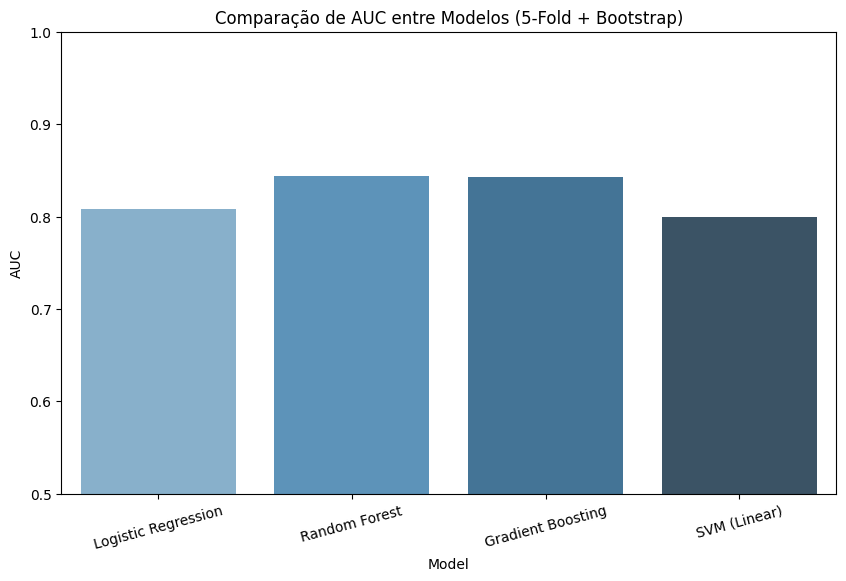

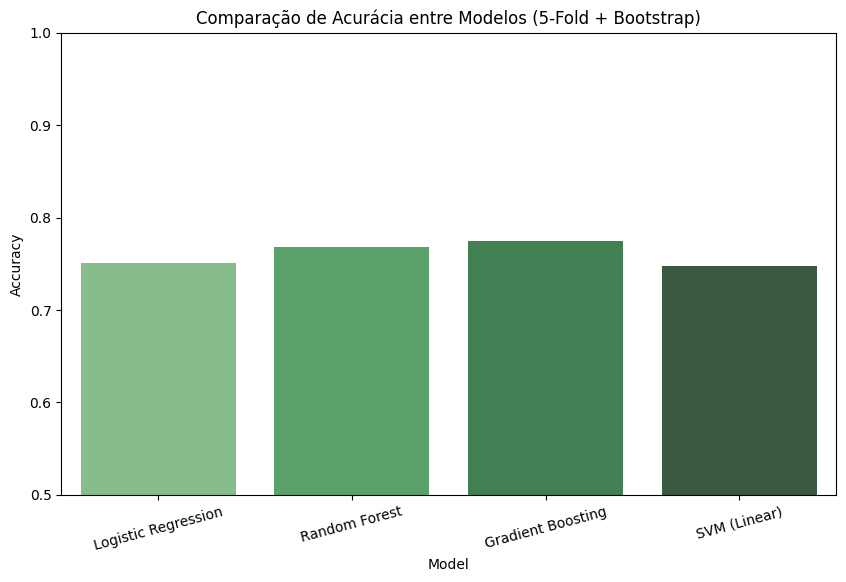

In [356]:

lr_mean = np.mean(lr_metrics, axis=0)
rf_mean = np.mean(rf_metrics, axis=0)
gb_mean = np.mean(gb_metrics, axis=0)
svm_mean = np.mean(svm_metrics, axis=0)

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting", "SVM (Linear)"],
    "Accuracy": [lr_mean[0], rf_mean[0], gb_mean[0], svm_mean[0]],
    "Sensitivity": [lr_mean[1], rf_mean[1], gb_mean[1], svm_mean[1]],
    "Specificity": [lr_mean[2], rf_mean[2], gb_mean[2], svm_mean[2]],
    "PPV": [lr_mean[7], rf_mean[7], gb_mean[7], svm_mean[7]],
    "NPV": [lr_mean[8], rf_mean[8], gb_mean[8], svm_mean[8]],
    "AUC": [
        np.mean(lr_auc),
        np.mean(rf_auc),
        np.mean(gb_auc),
        np.mean(svm_auc)
    ]
})

print("📊 Resultados Médios (5-Fold + Bootstrap 1000):")
display(results_df.round(3))



plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="AUC", data=results_df, palette="Blues_d")
plt.title("Comparação de AUC entre Modelos (5-Fold + Bootstrap)")
plt.ylim(0.5, 1)
plt.ylabel("AUC")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="Greens_d")
plt.title("Comparação de Acurácia entre Modelos (5-Fold + Bootstrap)")
plt.ylim(0.5, 1)
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()


Top 15 variáveis mais importantes — Gradient Boosting:



,Importância
MOMOPARK,0.2607
NACCLBDS,0.0862
PARKAGE,0.0849
POSTURE,0.0670
HANDALTR,0.0396
BRADYKIN,0.0369
NACCLBDE,0.0305
PDOTHR,0.0302
PARK,0.0295
PD,0.0291


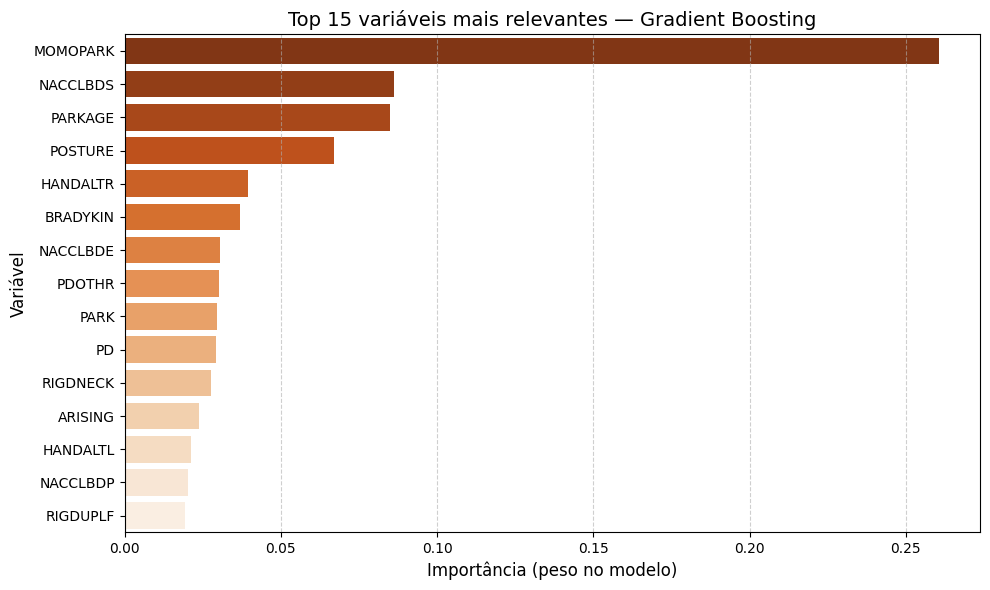

In [357]:

gb_best = gb_models[0]

feat_gb = pd.Series(
    gb_best.feature_importances_,
    index=X.columns[:len(gb_best.feature_importances_)]
)

top15_gb = feat_gb.sort_values(ascending=False).head(15)

print("Top 15 variáveis mais importantes — Gradient Boosting:\n")
display(top15_gb.round(4).to_frame("Importância"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_gb.values, y=top15_gb.index, palette="Oranges_r")
plt.title("Top 15 variáveis mais relevantes — Gradient Boosting", fontsize=14)
plt.xlabel("Importância (peso no modelo)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Top 15 variáveis mais importantes — SVM (Fold 1):



,Importância
GAIT,2.1142
NACCLBDS,0.8271
TRESTRFT,0.8182
HANDALTL,0.7970
MOMOPARK,0.7796
HANDMOVR,0.5944
DATSCAN,0.5765
TRESTLFT,0.5135
FACEXP,0.4965
HANDALTR,0.4866


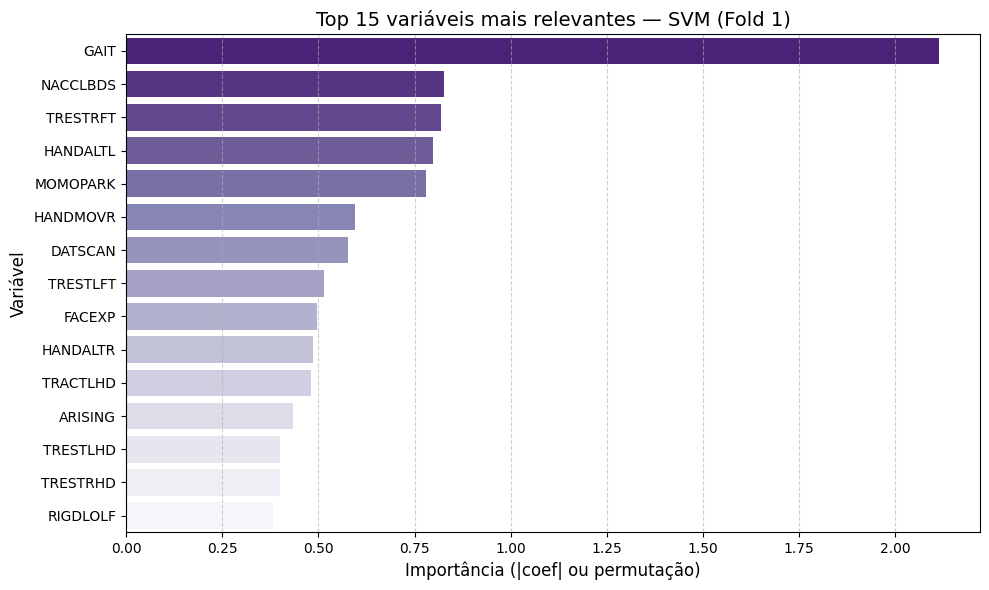

In [358]:

from sklearn.inspection import permutation_importance

svm_best = svm_models[0]

if hasattr(svm_best, "kernel") and svm_best.kernel == "linear":
    feat_svm = pd.Series(
        np.abs(svm_best.coef_[0]),
        index=X.columns[:len(svm_best.coef_[0])]
    )
else:
    print("SVM com kernel não linear — usando permutation importance...")
    perm = permutation_importance(svm_best, X_scaled, y_array, n_repeats=10, random_state=42, n_jobs=-1)
    feat_svm = pd.Series(perm.importances_mean, index=X.columns)

top15_svm = feat_svm.sort_values(ascending=False).head(15)

print("Top 15 variáveis mais importantes — SVM (Fold 1):\n")
display(top15_svm.round(4).to_frame("Importância"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_svm.values, y=top15_svm.index, palette="Purples_r")
plt.title("Top 15 variáveis mais relevantes — SVM (Fold 1)", fontsize=14)
plt.xlabel("Importância (|coef| ou permutação)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


🏆 Top 15 variáveis mais importantes — Logistic Regression (Fold 1):



,Peso |coef|
GAIT,2.2318
TRESTRFT,0.6591
MOMOPARK,0.6534
HANDALTL,0.6401
ARISING,0.4961
NACCLBDS,0.4766
TRESTLFT,0.4460
NACCLBDP,0.4455
FACEXP,0.4452
HANDALTR,0.4299


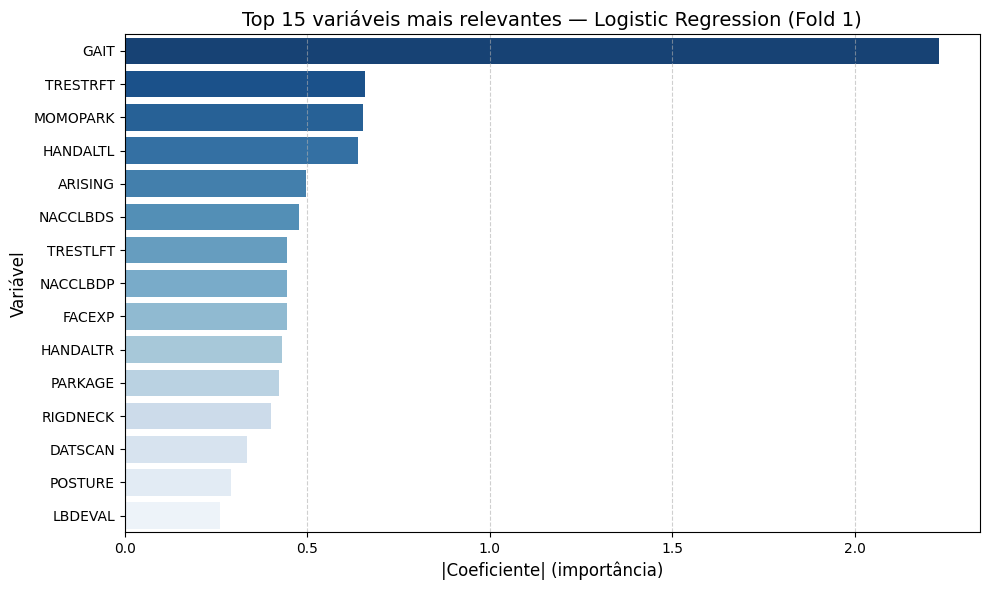

In [359]:


lr_best = lr_models[0]

coefs = pd.Series(
    np.abs(lr_best.coef_[0]),
    index=X.columns[:len(lr_best.coef_[0])]
)

top15_lr = coefs.sort_values(ascending=False).head(15)

print("🏆 Top 15 variáveis mais importantes — Logistic Regression (Fold 1):\n")
display(top15_lr.round(4).to_frame("Peso |coef|"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_lr.values, y=top15_lr.index, palette="Blues_r")
plt.title("Top 15 variáveis mais relevantes — Logistic Regression (Fold 1)", fontsize=14)
plt.xlabel("|Coeficiente| (importância)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Top 15 variáveis mais importantes — Random Forest (Fold 1):



,Importância
MOMOPARK,0.2507
PARKAGE,0.0786
NACCLBDS,0.0786
POSTURE,0.0687
DATSCAN,0.0553
HANDALTL,0.0316
ARISING,0.0301
BRADYKIN,0.0299
RIGDNECK,0.0279
HANDALTR,0.0278


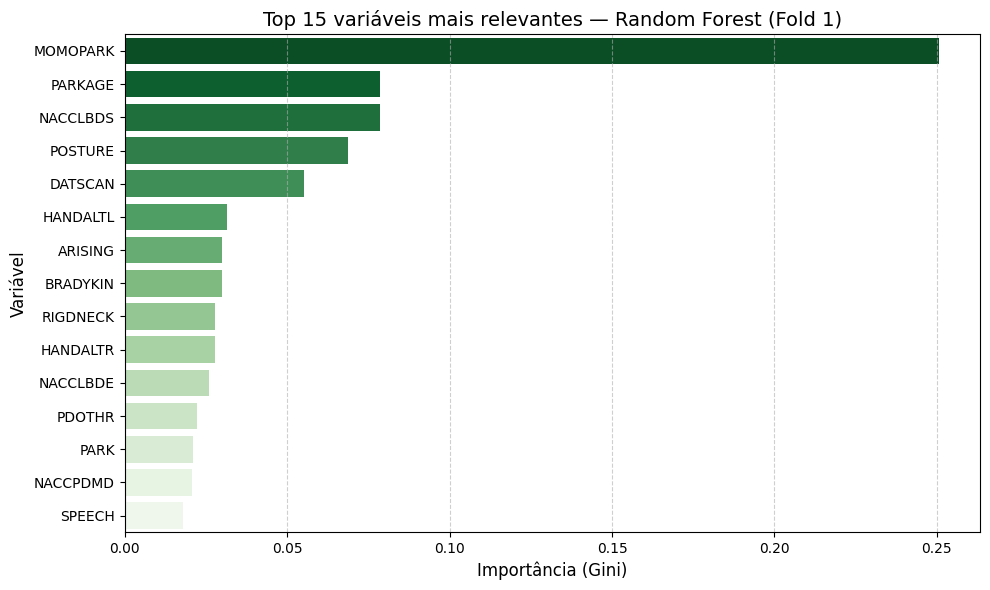

In [360]:

rf_best = rf_models[0]

feat_rf = pd.Series(
    rf_best.feature_importances_,
    index=X.columns[:len(rf_best.feature_importances_)]
)

top15_rf = feat_rf.sort_values(ascending=False).head(15)

print("Top 15 variáveis mais importantes — Random Forest (Fold 1):\n")
display(top15_rf.round(4).to_frame("Importância"))

plt.figure(figsize=(10,6))
sns.barplot(x=top15_rf.values, y=top15_rf.index, palette="Greens_r")
plt.title("Top 15 variáveis mais relevantes — Random Forest (Fold 1)", fontsize=14)
plt.xlabel("Importância (Gini)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Tabela comparativa — Top 15 variáveis por modelo:



,Logistic Regression,Random Forest,Gradient Boosting,SVM (Linear)
0,GAIT,MOMOPARK,MOMOPARK,GAIT
1,TRESTRFT,PARKAGE,NACCLBDS,NACCLBDS
2,MOMOPARK,NACCLBDS,PARKAGE,TRESTRFT
3,HANDALTL,POSTURE,POSTURE,HANDALTL
4,ARISING,DATSCAN,HANDALTR,MOMOPARK
5,NACCLBDS,HANDALTL,BRADYKIN,HANDMOVR
6,TRESTLFT,ARISING,NACCLBDE,DATSCAN
7,NACCLBDP,BRADYKIN,PDOTHR,TRESTLFT
8,FACEXP,RIGDNECK,PARK,FACEXP
9,HANDALTR,HANDALTR,PD,HANDALTR



Variáveis mais recorrentes entre modelos:



,Variável,Frequência
0,MOMOPARK,4
2,ARISING,4
3,NACCLBDS,4
4,HANDALTR,4
1,HANDALTL,4
5,RIGDNECK,3
6,PARKAGE,3
7,DATSCAN,3
8,POSTURE,3
13,BRADYKIN,2


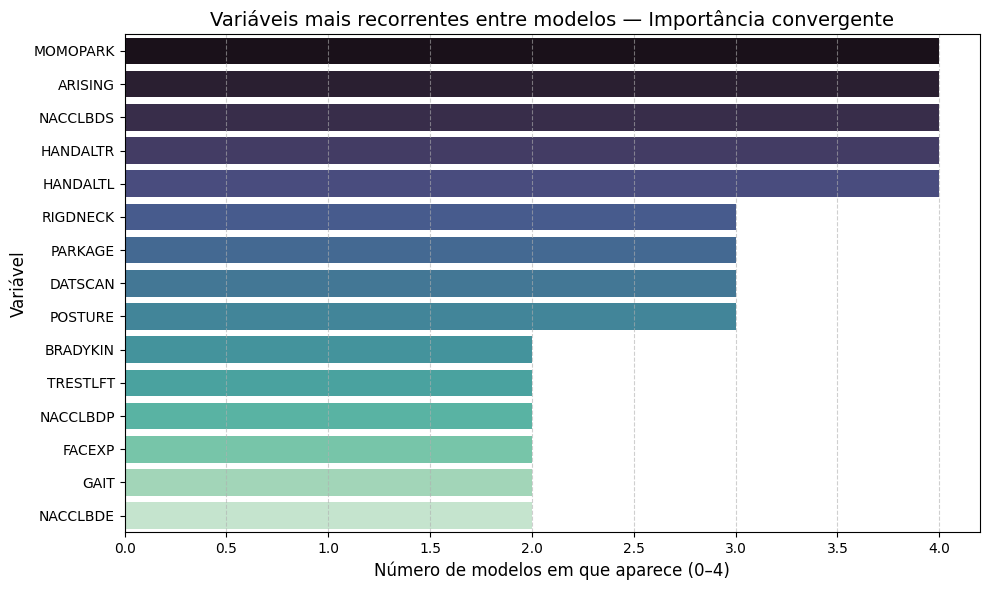

In [361]:

top_features_dict = {
    "Logistic Regression": list(top15_lr.index),
    "Random Forest": list(top15_rf.index),
    "Gradient Boosting": list(top15_gb.index),
    "SVM (Linear)": list(top15_svm.index)
}

df_top_features = pd.DataFrame({k: pd.Series(v) for k, v in top_features_dict.items()})

print("Tabela comparativa — Top 15 variáveis por modelo:\n")
display(df_top_features)

all_features = sum(top_features_dict.values(), [])
feature_counts = pd.Series(all_features).value_counts()

freq_df = feature_counts.reset_index()
freq_df.columns = ["Variável", "Frequência"]
freq_df = freq_df.sort_values(by="Frequência", ascending=False)

print("\nVariáveis mais recorrentes entre modelos:\n")
display(freq_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x="Frequência", y="Variável", data=freq_df.head(15), palette="mako")
plt.title("Variáveis mais recorrentes entre modelos — Importância convergente", fontsize=14)
plt.xlabel("Número de modelos em que aparece (0–4)", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Tabela 3 — Comparação dos modelos (5-Fold + Bootstrap 1000):


,Modelo,Accuracy,Sensitivity (Recall),Specificity,PPV,NPV,AUC
0,Logistic Regression,0.751,0.727,0.766,0.656,0.821,0.808
1,Random Forest,0.769,0.767,0.770,0.671,0.844,0.844
2,Gradient Boosting,0.774,0.637,0.858,0.734,0.795,0.843
3,SVM (Linear),0.748,0.702,0.776,0.658,0.810,0.799


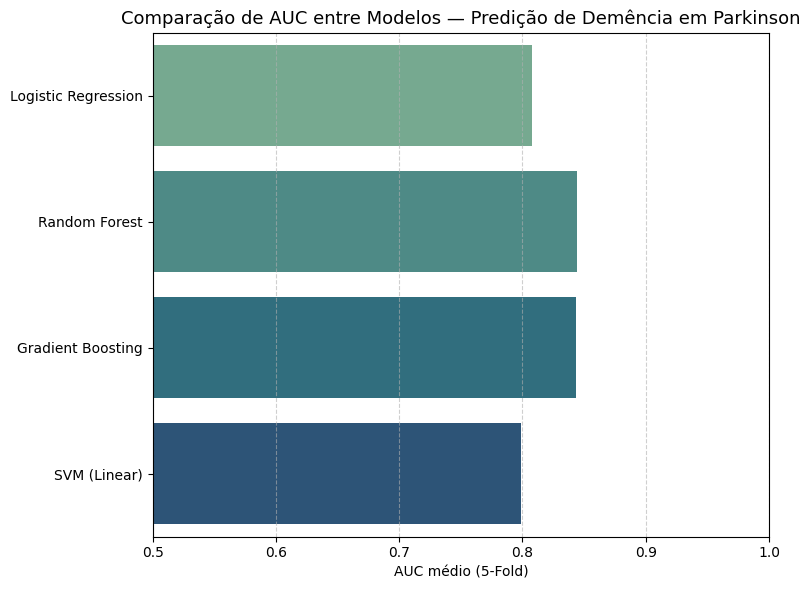

In [362]:

lr_mean = np.mean(lr_metrics, axis=0)
rf_mean = np.mean(rf_metrics, axis=0)
gb_mean = np.mean(gb_metrics, axis=0)
svm_mean = np.mean(svm_metrics, axis=0)

results_df = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM (Linear)'],
    'Accuracy': [lr_mean[0], rf_mean[0], gb_mean[0], svm_mean[0]],
    'Sensitivity (Recall)': [lr_mean[1], rf_mean[1], gb_mean[1], svm_mean[1]],
    'Specificity': [lr_mean[2], rf_mean[2], gb_mean[2], svm_mean[2]],
    'PPV': [lr_mean[7], rf_mean[7], gb_mean[7], svm_mean[7]],
    'NPV': [lr_mean[8], rf_mean[8], gb_mean[8], svm_mean[8]],
    'AUC': [
        np.mean(lr_auc),
        np.mean(rf_auc),
        np.mean(gb_auc),
        np.mean(svm_auc)
    ]
})

print("Tabela 3 — Comparação dos modelos (5-Fold + Bootstrap 1000):")
display(results_df.round(3))

plt.figure(figsize=(8, 6))
sns.barplot(x='AUC', y='Modelo', data=results_df, palette='crest')
plt.title('Comparação de AUC entre Modelos — Predição de Demência em Parkinson', fontsize=13)
plt.xlabel('AUC médio (5-Fold)')
plt.ylabel('')
plt.xlim(0.5, 1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


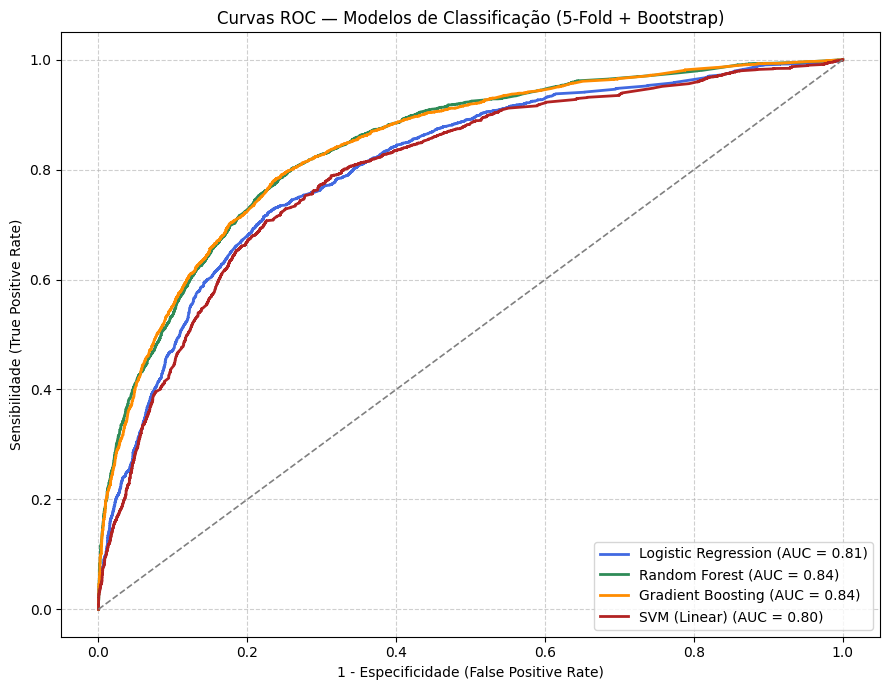

In [363]:
plt.figure(figsize=(9, 7))

fpr_lr, tpr_lr, _ = roc_curve(lr_true, lr_probs)
auc_lr = roc_auc_score(lr_true, lr_probs)
plt.plot(fpr_lr, tpr_lr, lw=2, color="royalblue", label=f"Logistic Regression (AUC = {auc_lr:.2f})")

fpr_rf, tpr_rf, _ = roc_curve(rf_true, rf_probs)
auc_rf = roc_auc_score(rf_true, rf_probs)
plt.plot(fpr_rf, tpr_rf, lw=2, color="seagreen", label=f"Random Forest (AUC = {auc_rf:.2f})")

fpr_gb, tpr_gb, _ = roc_curve(gb_true, gb_probs)
auc_gb = roc_auc_score(gb_true, gb_probs)
plt.plot(fpr_gb, tpr_gb, lw=2, color="darkorange", label=f"Gradient Boosting (AUC = {auc_gb:.2f})")

fpr_svm, tpr_svm, _ = roc_curve(svm_true, svm_probs)
auc_svm = roc_auc_score(svm_true, svm_probs)
plt.plot(fpr_svm, tpr_svm, lw=2, color="firebrick", label=f"SVM (Linear) (AUC = {auc_svm:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1.2)
plt.xlabel("1 - Especificidade (False Positive Rate)")
plt.ylabel("Sensibilidade (True Positive Rate)")
plt.title("Curvas ROC — Modelos de Classificação (5-Fold + Bootstrap)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [364]:
resultados_df = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM (Linear)'],
    'Accuracy': [lr_mean[0], rf_mean[0], gb_mean[0], svm_mean[0]],
    'Sensibilidade': [lr_mean[1], rf_mean[1], gb_mean[1], svm_mean[1]],
    'Especificidade': [lr_mean[2], rf_mean[2], gb_mean[2], svm_mean[2]],
    'PPV': [lr_mean[7], rf_mean[7], gb_mean[7], svm_mean[7]],
    'NPV': [lr_mean[8], rf_mean[8], gb_mean[8], svm_mean[8]],
    'AUC': [np.mean(lr_auc), np.mean(rf_auc), np.mean(gb_auc), np.mean(svm_auc)]
})

display(resultados_df.round(3))


,Modelo,Accuracy,Sensibilidade,Especificidade,PPV,NPV,AUC
0,Logistic Regression,0.751,0.727,0.766,0.656,0.821,0.808
1,Random Forest,0.769,0.767,0.770,0.671,0.844,0.844
2,Gradient Boosting,0.774,0.637,0.858,0.734,0.795,0.843
3,SVM (Linear),0.748,0.702,0.776,0.658,0.810,0.799


In [365]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


Resultados Médios — 5-Fold + Bootstrap (Tabela 3):


,Modelo,AUC,Accuracy,Sensibilidade,Especificidade,PPV,NPV
0,Logistic Regression,0.808,0.751,0.727,0.766,0.656,0.821
1,Random Forest,0.844,0.769,0.767,0.770,0.671,0.844
2,Gradient Boosting,0.843,0.774,0.637,0.858,0.734,0.795
3,SVM (Linear),0.799,0.748,0.702,0.776,0.658,0.810


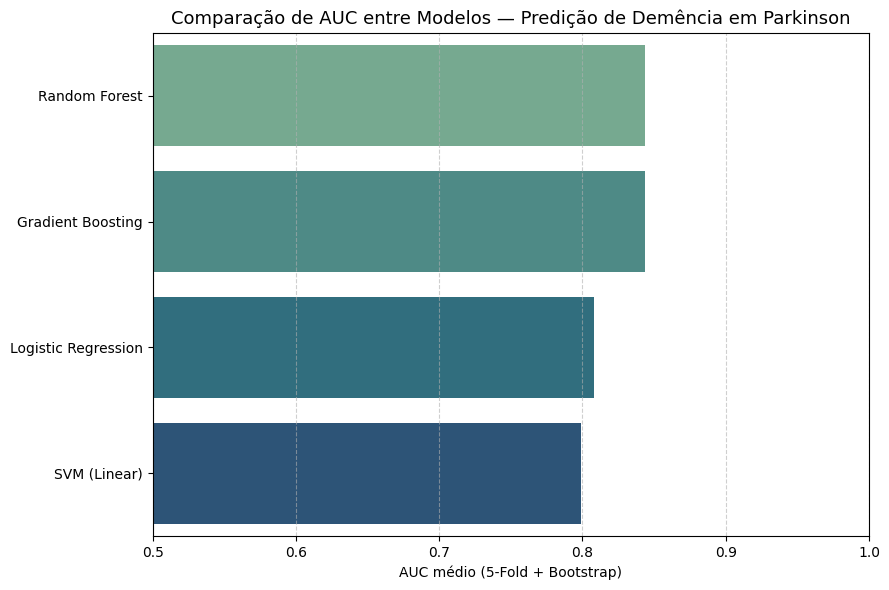

Tabela 3 exportada para 'results/Tabela3_Modelos_Parkinson.xlsx' com sucesso.


In [366]:

metric_names = [
    'accuracy', 'sensitivity', 'specificity', 'positive_likelihood',
    'negative_likelihood', 'false_positive_rate', 'false_negative_rate',
    'ppv', 'npv', 'positive_rate'
]

lr_mean = pd.Series(np.mean(lr_metrics, axis=0), index=metric_names)
rf_mean = pd.Series(np.mean(rf_metrics, axis=0), index=metric_names)
gb_mean = pd.Series(np.mean(gb_metrics, axis=0), index=metric_names)
svm_mean = pd.Series(np.mean(svm_metrics, axis=0), index=metric_names)

results_df = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest", "Gradient Boosting", "SVM (Linear)"],
    "AUC": [np.mean(lr_auc), np.mean(rf_auc), np.mean(gb_auc), np.mean(svm_auc)],
    "Accuracy": [lr_mean['accuracy'], rf_mean['accuracy'], gb_mean['accuracy'], svm_mean['accuracy']],
    "Sensibilidade": [lr_mean['sensitivity'], rf_mean['sensitivity'], gb_mean['sensitivity'], svm_mean['sensitivity']],
    "Especificidade": [lr_mean['specificity'], rf_mean['specificity'], gb_mean['specificity'], svm_mean['specificity']],
    "PPV": [lr_mean['ppv'], rf_mean['ppv'], gb_mean['ppv'], svm_mean['ppv']],
    "NPV": [lr_mean['npv'], rf_mean['npv'], gb_mean['npv'], svm_mean['npv']]
})

print("Resultados Médios — 5-Fold + Bootstrap (Tabela 3):")
display(results_df.round(3))

plt.figure(figsize=(9, 6))
sns.barplot(x="AUC", y="Modelo", data=results_df.sort_values("AUC", ascending=False), palette="crest")
plt.title("Comparação de AUC entre Modelos — Predição de Demência em Parkinson", fontsize=13)
plt.xlabel("AUC médio (5-Fold + Bootstrap)")
plt.ylabel("")
plt.xlim(0.5, 1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

output_path = "results/Tabela3_Modelos_Parkinson.xlsx"
os.makedirs("results", exist_ok=True)
results_df.round(4).to_excel(output_path, index=False)
print(f"Tabela 3 exportada para '{output_path}' com sucesso.")
